# Franka Push · Advanced Force-Feedback SAC + HER · AutoDL · MuJoCo 3

这是一份在现有 Franka Push SAC+HER 基线之上继续升级的**接触感知强化学习版本**。

## 核心增强

1. **MuJoCo 3.12 接触力反馈**
   - 仅提取 Franka 末端/手指 ↔ `obj` 的接触；
   - 使用 `mj_contactForce()`；
   - 将 contact-frame force 转换到 world frame；
   - 多接触点合成为物体所受的净接触力。

2. **HER-safe 力观测**
   - observation 增加：
     - `Fx, Fy, Fz`（归一化）
     - `||F||`
     - contact flag
     - contact count
     - 上一拍实际执行动作 `a_applied(t-1)`
   - **不把依赖 desired_goal 的力方向特征放进 observation**，否则 HER 重标记目标后会造成观测不一致。

3. **可选动作平滑**
   \[
   a_t^{applied}=\beta a_{t-1}^{applied}+(1-\beta)a_t^{RL}
   \]
   若启用，上一拍 applied action 同时进入 observation，使动态尽量保持 Markov。

4. **可选安全力惩罚**
   \[
   r_F=-\lambda_F\left[\max\left(0,\frac{\|F\|-F_{safe}}{F_{scale}}\right)\right]^2
   \]
   只惩罚超限接触力，不惩罚正常接触。

5. **Force-aware HER**
   - replay buffer 保存最小必要 info；
   - HER 重标记目标时，仍保留该 transition 的接触力/动作平滑代价；
   - Dense→Sparse 模式下，真实样本与 HER 样本都会按当前 reward phase 重算。

6. **完整评估**
   - success rate
   - final/min distance
   - mean/max contact force
   - contact ratio
   - mean action delta
   - native return / task-only return
   - checkpoint + CSV + TensorBoard

---

## 推荐实验顺序

默认配置是 **`PROFILE="force_obs_only"`**：

- 加力反馈 observation；
- 不加 force penalty；
- 不开 action smoothing；
- 奖励仍用现有任务奖励。

这样最适合先做：

> Position-only baseline vs. Position + Force observation

确认有效后，再切换到更复杂 profile。

## 1. 环境版本检查 + MuJoCo 3 joint compatibility patch

本 cell 不重新安装依赖。要求服务器已存在：

- `/root/panda_mujoco_gym`
- MuJoCo 3.12.0
- Gymnasium 1.3.0
- Gymnasium-Robotics 1.4.2
- Stable-Baselines3 2.9.0

In [1]:
import os
import sys
import importlib
from pathlib import Path

import numpy as np
import mujoco

REPO = Path("/root/panda_mujoco_gym")
if not REPO.exists():
    raise RuntimeError(
        "/root/panda_mujoco_gym 不存在，请先 clone 仓库。"
    )

os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

expected = {
    "mujoco": "3.12.0",
    "gymnasium": "1.3.0",
    "gymnasium_robotics": "1.4.2",
    "stable_baselines3": "2.9.0",
    "sb3_contrib": "2.9.0",
}

print("Python:", sys.version)
print("Working directory:", os.getcwd())

for name, exp in expected.items():
    mod = importlib.import_module(name)
    got = getattr(mod, "__version__", "unknown")
    print(f"{name}: {got} (expected {exp})")

assert int(mujoco.__version__.split(".")[0]) >= 3

# ---- MuJoCo 3 compatibility patch for gymnasium_robotics mujoco_utils ----
from gymnasium_robotics.utils import mujoco_utils

def _joint_meta(model, name):
    jid = mujoco.mj_name2id(
        model, mujoco.mjtObj.mjOBJ_JOINT, name
    )
    if jid < 0:
        raise RuntimeError(f"Joint not found: {name}")

    jt = int(model.jnt_type[jid])
    qadr = int(model.jnt_qposadr[jid])
    dadr = int(model.jnt_dofadr[jid])

    FREE = int(mujoco.mjtJoint.mjJNT_FREE)
    BALL = int(mujoco.mjtJoint.mjJNT_BALL)
    SLIDE = int(mujoco.mjtJoint.mjJNT_SLIDE)
    HINGE = int(mujoco.mjtJoint.mjJNT_HINGE)

    if jt == FREE:
        qn, vn = 7, 6
    elif jt == BALL:
        qn, vn = 4, 3
    elif jt in (SLIDE, HINGE):
        qn, vn = 1, 1
    else:
        raise RuntimeError(f"Unsupported joint type {jt}: {name}")

    return qadr, dadr, qn, vn

def set_joint_qpos_fix(model, data, name, value):
    qadr, _, qn, _ = _joint_meta(model, name)
    value = np.asarray(value, dtype=np.float64).reshape(-1)
    if qn == 1:
        data.qpos[qadr] = float(value[0])
    else:
        if value.size != qn:
            raise ValueError(f"{name}: expected {qn} qpos, got {value.size}")
        data.qpos[qadr:qadr+qn] = value

def get_joint_qpos_fix(model, data, name):
    qadr, _, qn, _ = _joint_meta(model, name)
    out = data.qpos[qadr:qadr+qn].copy()
    return float(out[0]) if qn == 1 else out

def set_joint_qvel_fix(model, data, name, value):
    _, dadr, _, vn = _joint_meta(model, name)
    value = np.asarray(value, dtype=np.float64).reshape(-1)
    if vn == 1:
        data.qvel[dadr] = float(value[0])
    else:
        if value.size != vn:
            raise ValueError(f"{name}: expected {vn} qvel, got {value.size}")
        data.qvel[dadr:dadr+vn] = value

def get_joint_qvel_fix(model, data, name):
    _, dadr, _, vn = _joint_meta(model, name)
    out = data.qvel[dadr:dadr+vn].copy()
    return float(out[0]) if vn == 1 else out

mujoco_utils.set_joint_qpos = set_joint_qpos_fix
mujoco_utils.get_joint_qpos = get_joint_qpos_fix
mujoco_utils.set_joint_qvel = set_joint_qvel_fix
mujoco_utils.get_joint_qvel = get_joint_qvel_fix

print("\nMuJoCo 3 joint compatibility patch applied.")

import gymnasium as gym
import panda_mujoco_gym

probe = gym.make("FrankaPushSparse-v0")
obs, info = probe.reset(seed=0)
for _ in range(3):
    obs, r, terminated, truncated, info = probe.step(
        probe.action_space.sample()
    )
probe.close()

print("Base Franka environment check PASSED.")

Python: 3.12.3 | packaged by Anaconda, Inc. | (main, May  6 2024, 19:46:43) [GCC 11.2.0]
Working directory: /root/panda_mujoco_gym
mujoco: 3.12.0 (expected 3.12.0)
gymnasium: 1.3.0 (expected 1.3.0)
gymnasium_robotics: 1.4.2 (expected 1.4.2)


AdroitHandRelocateDense-v1, AdroitHandHammerDense-v1, AdroitHandDoorDense-v1 environment's reward functions were updated in v1.2.1 without an environment version update. Therefore, use gymnasium-robotics==1.2.0 for v1 reproducibility or use v2 in gymnasium-robotics>=1.4.3. See https://github.com/Farama-Foundation/Gymnasium-Robotics/pull/220 for more details


stable_baselines3: 2.9.0 (expected 2.9.0)
sb3_contrib: 2.9.0 (expected 2.9.0)

MuJoCo 3 joint compatibility patch applied.
Base Franka environment check PASSED.


/root/miniconda3/lib/python3.12/site-packages/gymnasium/utils/passive_env_checker.py:226: UserWarning: WARN: Expects `terminated` signal to be a boolean, actual type: <class 'numpy.float32'>
  logger.warn(


## 2. 实验配置

### `REWARD_SCHEME`

可选：

- `"distance_layered"`：方案 A，按距离切换
- `"dense2sparse"`：方案 B，按训练进度切换

### `PROFILE`

可选：

- `"force_obs_only"`：**推荐起点**。只增加力反馈 observation。
- `"force_obs_smooth"`：力反馈 + action smoothing。
- `"force_safe_smooth"`：力反馈 + smoothing + 超限力惩罚 + 动作变化惩罚。

为了做严谨消融，建议每次只增加一个机制。

In [2]:
import csv
import json
import time
import random
import copy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
import torch

from IPython.display import display

import panda_mujoco_gym
from panda_mujoco_gym.envs.push import FrankaPushEnv

from stable_baselines3 import SAC, HerReplayBuffer
from stable_baselines3.common.callbacks import (
    BaseCallback,
    CallbackList,
    CheckpointCallback,
)
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.type_aliases import DictReplayBufferSamples
from stable_baselines3.common.vec_env import SubprocVecEnv, DummyVecEnv
from tqdm import tqdm


# ============================================================
# Experiment identity
# ============================================================

SEED = 42

# A: distance-based layered reward
# B: training-time Dense -> Sparse
REWARD_SCHEME = "distance_layered"
# REWARD_SCHEME = "dense2sparse"

PROFILE = "force_obs_only"
# PROFILE = "force_obs_smooth"
# PROFILE = "force_safe_smooth"


# ============================================================
# Training budget
# ============================================================

TOTAL_TIMESTEPS = 500_000
MAX_EPISODE_STEPS = 50

N_ENVS = 4
BATCH_SIZE = 512
BUFFER_SIZE = 1_000_000
LEARNING_STARTS = 5_000
LEARNING_RATE = 3e-4
GAMMA = 0.95
TAU = 0.005
TRAIN_FREQ = 4
NET_ARCH = [256, 256]

N_SAMPLED_GOAL = 4
GOAL_SELECTION_STRATEGY = "future"

EVAL_FREQ = 20_000
N_EVAL_EPISODES = 20
CHECKPOINT_FREQ = 50_000


# ============================================================
# Task reward
# ============================================================

REWARD_A = 1.0
REWARD_K = 5.0

D_SWITCH = 0.12
D_SUCCESS = 0.05

DENSE_K = 5.0
DENSE_FRACTION = 0.40
SWITCH_STEP = int(TOTAL_TIMESTEPS * DENSE_FRACTION)

# Fixed horizon keeps A/B episode structure identical
TERMINATE_ON_SUCCESS = False


# ============================================================
# Force observation
# ============================================================

USE_FORCE_OBS = True

# only object <-> end-effector subtree contacts are counted
CONTACT_BODY_NAMES = (
    "hand",
    "left_finger",
    "right_finger",
    "link7",
)

FORCE_OBS_SCALE = 50.0       # N; observation normalization scale
FORCE_OBS_CLIP = 2.0         # normalized component clipping
CONTACT_COUNT_SCALE = 4.0


# ============================================================
# Optional action smoothing
# ============================================================

USE_ACTION_SMOOTHING = PROFILE in {
    "force_obs_smooth",
    "force_safe_smooth",
}

ACTION_SMOOTH_BETA = 0.65


# ============================================================
# Optional auxiliary penalties
# ============================================================

USE_FORCE_PENALTY = PROFILE == "force_safe_smooth"
USE_SMOOTH_PENALTY = PROFILE == "force_safe_smooth"

FORCE_SAFE = 15.0            # N; no penalty below this
FORCE_PENALTY_SCALE = 25.0   # N
LAMBDA_FORCE = 0.10

LAMBDA_SMOOTH = 0.02


# ============================================================
# Device / output
# ============================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

data_root = (
    Path("/root/autodl-tmp")
    if Path("/root/autodl-tmp").exists()
    else Path("/root")
)

stamp = time.strftime("%Y%m%d_%H%M%S")

RUN_NAME = (
    f"SAC_HER_Force_{REWARD_SCHEME}_{PROFILE}"
    f"_seed{SEED}_{stamp}"
)

ROOT = data_root / "franka_force_feedback" / RUN_NAME
TB_DIR = ROOT / "tensorboard"
MODEL_DIR = ROOT / "models"
EVAL_DIR = ROOT / "eval"
FIG_DIR = ROOT / "figures"

for p in [TB_DIR, MODEL_DIR, EVAL_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.set_float32_matmul_precision("high")

config = {
    k: v for k, v in globals().copy().items()
    if k in {
        "SEED", "REWARD_SCHEME", "PROFILE",
        "TOTAL_TIMESTEPS", "MAX_EPISODE_STEPS",
        "N_ENVS", "BATCH_SIZE", "BUFFER_SIZE",
        "LEARNING_STARTS", "LEARNING_RATE",
        "GAMMA", "TAU", "TRAIN_FREQ", "NET_ARCH",
        "N_SAMPLED_GOAL", "GOAL_SELECTION_STRATEGY",
        "REWARD_A", "REWARD_K", "D_SWITCH", "D_SUCCESS",
        "DENSE_K", "DENSE_FRACTION", "SWITCH_STEP",
        "TERMINATE_ON_SUCCESS",
        "FORCE_OBS_SCALE", "FORCE_SAFE",
        "USE_ACTION_SMOOTHING", "ACTION_SMOOTH_BETA",
        "USE_FORCE_PENALTY", "LAMBDA_FORCE",
        "USE_SMOOTH_PENALTY", "LAMBDA_SMOOTH",
        "DEVICE",
    }
}
(ROOT / "config.json").write_text(
    json.dumps(config, indent=2)
)

print("Run:", RUN_NAME)
print("Reward scheme:", REWARD_SCHEME)
print("Profile:", PROFILE)
print("Device:", DEVICE)
print("Timesteps:", TOTAL_TIMESTEPS)
print("Switch step:", SWITCH_STEP if REWARD_SCHEME == "dense2sparse" else "N/A")
print("Action smoothing:", USE_ACTION_SMOOTHING)
print("Force penalty:", USE_FORCE_PENALTY)
print("Smooth penalty:", USE_SMOOTH_PENALTY)
print("Output:", ROOT)

Run: SAC_HER_Force_distance_layered_force_obs_only_seed42_20260901_144757
Reward scheme: distance_layered
Profile: force_obs_only
Device: cuda
Timesteps: 500000
Switch step: N/A
Action smoothing: False
Force penalty: False
Smooth penalty: False
Output: /root/autodl-tmp/franka_force_feedback/SAC_HER_Force_distance_layered_force_obs_only_seed42_20260901_144757


## 3. 高级接触感知 Franka Push 环境

### 为什么按 body ID 识别接触？

原 Franka MJCF 中很多 fingertip collision geom 没有显式名字，因此不能可靠地用 geom name 匹配。

这里使用：

- `obj` body
- `hand`
- `left_finger`
- `right_finger`
- `link7`

对应 geom 的 `bodyid` 来筛选，只统计：

\[
\text{Franka EE subtree} \leftrightarrow \text{object}
\]

### 力方向

`mj_contactForce()` 返回 contact frame 下的 6D wrench。

MuJoCo 的 `contact.frame` 把 frame axes 按**行**存储，因此：

\[
F_{world}=R_{contact}^{T}F_{contact}
\]

并统一转换为**作用在 object 上的力**再求和。

In [3]:
class FrankaPushForceEnv(FrankaPushEnv):
    """
    Franka Push with HER-safe force/contact observations.

    Extra observation dimensions:
        0:3   normalized world force on object
        3     normalized force norm
        4     contact flag
        5     normalized contact count
        6:9   previous applied Cartesian action

    Total extra dims = 9.
    """

    def __init__(
        self,
        reward_scheme="distance_layered",
        reward_a=1.0,
        reward_k=5.0,
        d_switch=0.12,
        d_success=0.05,
        dense_k=5.0,
        reward_mode="dense",
        max_episode_steps=50,
        terminate_on_success=False,
        use_force_obs=True,
        force_obs_scale=50.0,
        force_obs_clip=2.0,
        contact_body_names=CONTACT_BODY_NAMES,
        use_action_smoothing=False,
        action_smooth_beta=0.65,
        use_force_penalty=False,
        force_safe=15.0,
        force_penalty_scale=25.0,
        lambda_force=0.10,
        use_smooth_penalty=False,
        lambda_smooth=0.02,
        render_mode=None,
    ):
        if reward_scheme not in {"distance_layered", "dense2sparse"}:
            raise ValueError(reward_scheme)

        if not (0.0 < d_success < d_switch):
            raise ValueError("Require 0 < d_success < d_switch.")

        self.reward_scheme = str(reward_scheme)

        self.reward_a = float(reward_a)
        self.reward_k = float(reward_k)
        self.d_switch = float(d_switch)
        self.d_success = float(d_success)

        self.dense_k = float(dense_k)
        self.reward_mode = str(reward_mode)

        self.custom_max_episode_steps = int(max_episode_steps)
        self.terminate_on_success = bool(terminate_on_success)
        self._custom_elapsed_steps = 0

        self.use_force_obs = bool(use_force_obs)
        self.force_obs_scale = float(force_obs_scale)
        self.force_obs_clip = float(force_obs_clip)

        self.contact_body_names = tuple(contact_body_names)
        self._object_body_id_cache = None
        self._ee_body_ids_cache = None

        self.use_action_smoothing = bool(use_action_smoothing)
        self.action_smooth_beta = float(action_smooth_beta)

        # action dimension in FrankaPush = 3
        self._prev_applied_action = np.zeros(3, dtype=np.float32)

        self.use_force_penalty = bool(use_force_penalty)
        self.force_safe = float(force_safe)
        self.force_penalty_scale = float(force_penalty_scale)
        self.lambda_force = float(lambda_force)

        self.use_smooth_penalty = bool(use_smooth_penalty)
        self.lambda_smooth = float(lambda_smooth)

        super().__init__(
            reward_type="dense",
            render_mode=render_mode,
        )

        self.distance_threshold = self.d_success

    # --------------------------------------------------------
    # Reward phase
    # --------------------------------------------------------

    def set_reward_mode(self, mode):
        mode = str(mode).lower()
        if mode not in {"dense", "sparse"}:
            raise ValueError(mode)
        self.reward_mode = mode
        return mode

    def get_reward_mode(self):
        return self.reward_mode

    # --------------------------------------------------------
    # Contact-force extraction
    # --------------------------------------------------------

    def _resolve_contact_body_ids(self):
        if self._object_body_id_cache is None:
            obj_id = mujoco.mj_name2id(
                self.model,
                mujoco.mjtObj.mjOBJ_BODY,
                "obj",
            )
            if obj_id < 0:
                raise RuntimeError("Object body 'obj' not found.")
            self._object_body_id_cache = int(obj_id)

        if self._ee_body_ids_cache is None:
            ids = set()
            for name in self.contact_body_names:
                bid = mujoco.mj_name2id(
                    self.model,
                    mujoco.mjtObj.mjOBJ_BODY,
                    name,
                )
                if bid >= 0:
                    ids.add(int(bid))

            if not ids:
                raise RuntimeError(
                    f"No EE contact bodies found: {self.contact_body_names}"
                )

            self._ee_body_ids_cache = ids

        return self._object_body_id_cache, self._ee_body_ids_cache

    def get_object_contact_force(self):
        """
        Returns
        -------
        force_world_on_object : (3,)
            Sum of EE-object contact forces, in world frame, Newtons.
        contact_count : int
            Number of matching contact points.
        """
        obj_bid, ee_bids = self._resolve_contact_body_ids()

        net_force = np.zeros(3, dtype=np.float64)
        count = 0

        for i in range(int(self.data.ncon)):
            con = self.data.contact[i]

            g1 = int(con.geom1)
            g2 = int(con.geom2)

            if g1 < 0 or g2 < 0:
                continue

            b1 = int(self.model.geom_bodyid[g1])
            b2 = int(self.model.geom_bodyid[g2])

            relevant = (
                (b1 == obj_bid and b2 in ee_bids)
                or
                (b2 == obj_bid and b1 in ee_bids)
            )
            if not relevant:
                continue

            wrench_contact = np.zeros(6, dtype=np.float64)
            mujoco.mj_contactForce(
                self.model,
                self.data,
                i,
                wrench_contact,
            )

            # contact.frame stores frame axes as rows.
            # local -> world: R.T @ f_local
            frame = np.asarray(con.frame, dtype=np.float64).reshape(3, 3)
            force_world_on_geom2 = frame.T @ wrench_contact[:3]

            # mj_contactForce convention corresponds to force on geom2.
            if b2 == obj_bid:
                force_on_object = force_world_on_geom2
            else:
                force_on_object = -force_world_on_geom2

            net_force += force_on_object
            count += 1

        return net_force.astype(np.float32), int(count)

    def _force_features(self):
        force_world, count = self.get_object_contact_force()
        force_norm = float(np.linalg.norm(force_world))

        f_normed = np.clip(
            force_world / self.force_obs_scale,
            -self.force_obs_clip,
            self.force_obs_clip,
        ).astype(np.float32)

        norm_feature = np.array(
            [min(force_norm / self.force_obs_scale, self.force_obs_clip)],
            dtype=np.float32,
        )

        contact_flag = np.array(
            [1.0 if count > 0 else 0.0],
            dtype=np.float32,
        )

        count_feature = np.array(
            [min(count / CONTACT_COUNT_SCALE, 1.0)],
            dtype=np.float32,
        )

        features = np.concatenate(
            [
                f_normed,
                norm_feature,
                contact_flag,
                count_feature,
                self._prev_applied_action.astype(np.float32),
            ]
        )

        return features, force_world, force_norm, count

    # --------------------------------------------------------
    # HER-safe observation
    # --------------------------------------------------------

    def _get_obs(self):
        obs = super()._get_obs()

        if self.use_force_obs:
            force_features, _, _, _ = self._force_features()
            obs["observation"] = np.concatenate(
                [
                    obs["observation"].astype(np.float32),
                    force_features,
                ]
            ).astype(np.float32)

        return obs

    # --------------------------------------------------------
    # Reward
    # --------------------------------------------------------

    @staticmethod
    def _info_values(info, key, target_shape):
        """
        Extract scalar transition-dependent terms from info for both:
        - normal env step: dict
        - HER vectorized recomputation: list/np.ndarray of dict
        """
        if np.prod(target_shape, dtype=int) == 1:
            if isinstance(info, dict):
                return np.asarray(
                    info.get(key, 0.0),
                    dtype=np.float32,
                ).reshape(target_shape)

        if isinstance(info, dict):
            val = float(info.get(key, 0.0))
            return np.full(target_shape, val, dtype=np.float32)

        info_list = list(info)
        vals = [
            float(x.get(key, 0.0)) if isinstance(x, dict) else 0.0
            for x in info_list
        ]
        return np.asarray(vals, dtype=np.float32).reshape(target_shape)

    def _task_reward(self, achieved_goal, desired_goal):
        ag = np.asarray(achieved_goal, dtype=np.float32)
        dg = np.asarray(desired_goal, dtype=np.float32)
        d = np.linalg.norm(ag - dg, axis=-1)

        if self.reward_scheme == "distance_layered":
            outer_reward = (
                -1.0
                - self.reward_a
                * (
                    np.tanh(self.reward_k * d)
                    - np.tanh(self.reward_k * self.d_switch)
                )
            )

            reward = np.where(
                d > self.d_switch,
                outer_reward,
                -1.0,
            )

            reward = np.where(
                d <= self.d_success,
                0.0,
                reward,
            )

        else:
            if self.reward_mode == "dense":
                reward = -np.tanh(self.dense_k * d)
            else:
                reward = np.where(
                    d <= self.d_success,
                    0.0,
                    -1.0,
                )

        return np.asarray(reward, dtype=np.float32)

    def compute_reward(self, achieved_goal, desired_goal, info):
        task = self._task_reward(
            achieved_goal,
            desired_goal,
        )

        scalar = task.ndim == 0
        target_shape = task.shape if not scalar else ()

        total = task.astype(np.float32, copy=True)

        if self.use_force_penalty:
            force_norm = self._info_values(
                info,
                "force_norm",
                target_shape,
            )

            excess = np.maximum(
                0.0,
                (force_norm - self.force_safe)
                / self.force_penalty_scale,
            )

            total = total - self.lambda_force * excess**2

        if self.use_smooth_penalty:
            action_delta = self._info_values(
                info,
                "action_delta_norm",
                target_shape,
            )

            total = total - self.lambda_smooth * action_delta**2

        total = np.asarray(total, dtype=np.float32)

        return float(total) if total.ndim == 0 else total

    # --------------------------------------------------------
    # Dynamics / action smoothing
    # --------------------------------------------------------

    def reset(self, *, seed=None, options=None):
        self._custom_elapsed_steps = 0
        self._prev_applied_action = np.zeros(3, dtype=np.float32)
        return super().reset(seed=seed, options=options)

    def step(self, action):
        raw_action = np.asarray(action, dtype=np.float32).copy()
        raw_action = np.clip(
            raw_action,
            self.action_space.low,
            self.action_space.high,
        )

        prev = self._prev_applied_action.copy()

        if self.use_action_smoothing:
            beta = self.action_smooth_beta
            applied = (
                beta * prev
                + (1.0 - beta) * raw_action
            )
        else:
            applied = raw_action

        applied = np.clip(
            applied,
            self.action_space.low,
            self.action_space.high,
        ).astype(np.float32)

        action_delta_norm = float(
            np.linalg.norm(applied - prev)
        )

        # Set before super.step(), so next observation contains a_applied(t)
        self._prev_applied_action = applied.copy()

        obs, _, terminated, truncated, info = super().step(applied)

        self._custom_elapsed_steps += 1

        force_world, contact_count = self.get_object_contact_force()
        force_norm = float(np.linalg.norm(force_world))

        distance = float(
            np.linalg.norm(
                obs["achieved_goal"]
                - obs["desired_goal"]
            )
        )
        success = bool(distance <= self.d_success)

        info = dict(info)
        info.update(
            {
                "is_success": success,
                "distance_to_goal": distance,
                "force_x": float(force_world[0]),
                "force_y": float(force_world[1]),
                "force_z": float(force_world[2]),
                "force_norm": force_norm,
                "contact_count": int(contact_count),
                "in_contact": bool(contact_count > 0),
                "raw_action_norm": float(np.linalg.norm(raw_action)),
                "applied_action_norm": float(np.linalg.norm(applied)),
                "action_delta_norm": action_delta_norm,
                "reward_mode": (
                    self.reward_mode
                    if self.reward_scheme == "dense2sparse"
                    else "distance_layered"
                ),
            }
        )

        task_reward = float(
            np.asarray(
                self._task_reward(
                    obs["achieved_goal"],
                    obs["desired_goal"],
                )
            )
        )

        total_reward = float(
            self.compute_reward(
                obs["achieved_goal"],
                obs["desired_goal"],
                info,
            )
        )

        info["task_reward"] = task_reward
        info["total_reward"] = total_reward
        info["aux_penalty"] = total_reward - task_reward

        terminated = (
            success
            if self.terminate_on_success
            else False
        )

        truncated = bool(
            self._custom_elapsed_steps
            >= self.custom_max_episode_steps
        )

        return (
            obs,
            total_reward,
            bool(terminated),
            bool(truncated),
            info,
        )


class GoalMonitor(Monitor):
    def compute_reward(self, achieved_goal, desired_goal, info):
        return self.env.compute_reward(
            achieved_goal,
            desired_goal,
            info,
        )

    def set_reward_mode(self, mode):
        return self.env.set_reward_mode(mode)

    def get_reward_mode(self):
        return self.env.get_reward_mode()

## 4. 力反馈环境自检

这里检查：

- observation shape 是否扩展；
- contact body 是否正确解析；
- force feature 是否 finite；
- step 返回 bool；
- reward 是否能批量计算。

随机动作未必会碰到物体，因此 `force_norm=0` 本身不代表传感器有问题。

In [4]:
def build_env(render_mode=None):
    return FrankaPushForceEnv(
        reward_scheme=REWARD_SCHEME,
        reward_a=REWARD_A,
        reward_k=REWARD_K,
        d_switch=D_SWITCH,
        d_success=D_SUCCESS,
        dense_k=DENSE_K,
        reward_mode="dense",
        max_episode_steps=MAX_EPISODE_STEPS,
        terminate_on_success=TERMINATE_ON_SUCCESS,
        use_force_obs=USE_FORCE_OBS,
        force_obs_scale=FORCE_OBS_SCALE,
        force_obs_clip=FORCE_OBS_CLIP,
        contact_body_names=CONTACT_BODY_NAMES,
        use_action_smoothing=USE_ACTION_SMOOTHING,
        action_smooth_beta=ACTION_SMOOTH_BETA,
        use_force_penalty=USE_FORCE_PENALTY,
        force_safe=FORCE_SAFE,
        force_penalty_scale=FORCE_PENALTY_SCALE,
        lambda_force=LAMBDA_FORCE,
        use_smooth_penalty=USE_SMOOTH_PENALTY,
        lambda_smooth=LAMBDA_SMOOTH,
        render_mode=render_mode,
    )


test_env = build_env()

obs, info = test_env.reset(seed=SEED)

print("Observation shape:", obs["observation"].shape)
print("Achieved goal:", obs["achieved_goal"])
print("Desired goal:", obs["desired_goal"])
print("Action space:", test_env.action_space)

obj_bid, ee_bids = test_env._resolve_contact_body_ids()

print("Object body id:", obj_bid)
print(
    "EE bodies:",
    {
        name: mujoco.mj_name2id(
            test_env.model,
            mujoco.mjtObj.mjOBJ_BODY,
            name,
        )
        for name in CONTACT_BODY_NAMES
    },
)

f, n = test_env.get_object_contact_force()
print("Initial object force [N]:", f)
print("Initial contact count:", n)

# vectorized reward check for HER
ag = np.stack([obs["achieved_goal"]] * 4)
dg = np.stack([obs["desired_goal"]] * 4)

infos = [
    {
        "force_norm": 0.0,
        "action_delta_norm": 0.0,
    }
    for _ in range(4)
]

rv = test_env.compute_reward(ag, dg, infos)

print("Vectorized reward shape:", rv.shape)
print("Vectorized reward:", rv)

max_force = 0.0
contact_steps = 0

for i in range(50):
    action = test_env.action_space.sample()

    obs, reward, terminated, truncated, info = test_env.step(action)

    assert isinstance(terminated, bool)
    assert isinstance(truncated, bool)
    assert np.all(np.isfinite(obs["observation"]))

    max_force = max(max_force, info["force_norm"])
    contact_steps += int(info["in_contact"])

    if terminated or truncated:
        obs, info = test_env.reset()

print("Random-test max force:", max_force, "N")
print("Random-test contact steps:", contact_steps)
print("Force-feedback environment check PASSED.")

test_env.close()

Observation shape: (27,)
Achieved goal: [ 0.68218681 -0.01833647  0.01995554]
Desired goal: [ 0.65921041 -0.1217468   0.01995554]
Action space: Box(-1.0, 1.0, (3,), float32)
Object body id: 15
EE bodies: {'hand': 10, 'left_finger': 12, 'right_finger': 13, 'link7': 9}
Initial object force [N]: [0. 0. 0.]
Initial contact count: 0
Vectorized reward shape: (4,)
Vectorized reward: [-1. -1. -1. -1.]
Random-test max force: 46.053794860839844 N
Random-test contact steps: 2
Force-feedback environment check PASSED.


## 5. 可选：查看当前 contact 明细

如果后续需要确认“到底是哪几个 body 在和物体接触”，可以在有接触的状态调用下面函数。

In [5]:
def describe_contacts(env):
    rows = []

    for i in range(int(env.data.ncon)):
        con = env.data.contact[i]

        g1 = int(con.geom1)
        g2 = int(con.geom2)

        if g1 < 0 or g2 < 0:
            continue

        b1 = int(env.model.geom_bodyid[g1])
        b2 = int(env.model.geom_bodyid[g2])

        geom1_name = mujoco.mj_id2name(
            env.model,
            mujoco.mjtObj.mjOBJ_GEOM,
            g1,
        )
        geom2_name = mujoco.mj_id2name(
            env.model,
            mujoco.mjtObj.mjOBJ_GEOM,
            g2,
        )

        body1_name = mujoco.mj_id2name(
            env.model,
            mujoco.mjtObj.mjOBJ_BODY,
            b1,
        )
        body2_name = mujoco.mj_id2name(
            env.model,
            mujoco.mjtObj.mjOBJ_BODY,
            b2,
        )

        wrench = np.zeros(6)
        mujoco.mj_contactForce(
            env.model,
            env.data,
            i,
            wrench,
        )

        rows.append(
            {
                "contact_id": i,
                "geom1": geom1_name,
                "body1": body1_name,
                "geom2": geom2_name,
                "body2": body2_name,
                "force_local_norm": float(
                    np.linalg.norm(wrench[:3])
                ),
                "penetration": float(con.dist),
            }
        )

    return pd.DataFrame(rows)

## 6. Force-aware HER Replay Buffer

### 为什么需要保存 info？

如果启用安全力惩罚：

\[
r=r_{task}(g)+r_F(F)+r_{\Delta a}
\]

HER 只替换目标 \(g\)，但同一 transition 的真实接触力 \(F\) 不应被改变。

因此 HER 重算奖励时需要保留：

- `force_norm`
- `action_delta_norm`

同时保留 `TimeLimit.truncated` 供 SB3 正确处理 timeout。

为减少内存，不保存整份大 info，只保存上述最小字段。

In [6]:
class CompactInfoHerReplayBuffer(HerReplayBuffer):
    """
    HER buffer that stores only reward-relevant info fields.
    """

    @staticmethod
    def _compact_info(info):
        return {
            "force_norm": float(info.get("force_norm", 0.0)),
            "action_delta_norm": float(
                info.get("action_delta_norm", 0.0)
            ),
            "TimeLimit.truncated": bool(
                info.get("TimeLimit.truncated", False)
            ),
        }

    def add(
        self,
        obs,
        next_obs,
        action,
        reward,
        done,
        infos,
    ):
        compact_infos = [
            self._compact_info(info)
            for info in infos
        ]

        super().add(
            obs,
            next_obs,
            action,
            reward,
            done,
            compact_infos,
        )


class PhaseAwareForceHerReplayBuffer(CompactInfoHerReplayBuffer):
    """
    Used only by training-time Dense -> Sparse.

    After phase switch, real transitions are re-evaluated using the
    current reward function, including transition-dependent force/smooth
    penalties from stored compact info.

    HER virtual transitions are already recomputed by HerReplayBuffer.
    """

    def _get_real_samples(
        self,
        batch_indices,
        env_indices,
        env=None,
    ):
        obs_raw = {
            key: obs[batch_indices, env_indices, :]
            for key, obs in self.observations.items()
        }

        next_raw = {
            key: obs[batch_indices, env_indices, :]
            for key, obs in self.next_observations.items()
        }

        infos = copy.deepcopy(
            self.infos[batch_indices, env_indices]
        )

        if self.env is None:
            raise RuntimeError(
                "Replay buffer has no VecEnv."
            )

        rewards = self.env.env_method(
            "compute_reward",
            next_raw["achieved_goal"],
            obs_raw["desired_goal"],
            infos,
            indices=[0],
        )[0]

        rewards = np.asarray(
            rewards,
            dtype=np.float32,
        )

        obs = self._normalize_obs(
            obs_raw,
            env,
        )

        nxt = self._normalize_obs(
            next_raw,
            env,
        )

        dones = (
            self.dones[batch_indices, env_indices]
            * (
                1
                - self.timeouts[
                    batch_indices,
                    env_indices,
                ]
            )
        )

        rewards = self._normalize_reward(
            rewards.reshape(-1, 1),
            env,
        )

        return DictReplayBufferSamples(
            observations={
                k: self.to_torch(v)
                for k, v in obs.items()
            },
            actions=self.to_torch(
                self.actions[
                    batch_indices,
                    env_indices,
                ]
            ),
            next_observations={
                k: self.to_torch(v)
                for k, v in nxt.items()
            },
            dones=self.to_torch(
                dones
            ).reshape(-1, 1),
            rewards=self.to_torch(rewards),
        )

## 7. 并行 MuJoCo 训练环境

In [7]:
def make_worker(rank):
    def _init():
        # Avoid each MuJoCo worker spawning many BLAS threads.
        os.environ["OMP_NUM_THREADS"] = "1"
        os.environ["MKL_NUM_THREADS"] = "1"

        env = build_env()
        env.reset(seed=SEED + rank)

        return GoalMonitor(env)

    return _init


for name in ["train_env", "eval_env"]:
    old = globals().get(name)
    if old is not None:
        try:
            old.close()
        except Exception:
            pass


try:
    train_env = SubprocVecEnv(
        [
            make_worker(i)
            for i in range(N_ENVS)
        ],
        start_method="fork",
    )
    backend = "SubprocVecEnv"

except Exception as exc:
    print(
        "SubprocVecEnv failed; fallback to DummyVecEnv:",
        type(exc).__name__,
        exc,
    )

    train_env = DummyVecEnv(
        [
            make_worker(i)
            for i in range(N_ENVS)
        ]
    )

    backend = "DummyVecEnv"


eval_env = build_env()
eval_env.reset(seed=SEED + 10_000)

print("Backend:", backend)
print("n_envs:", train_env.num_envs)
print("Observation space:")
print(train_env.observation_space)

Backend: SubprocVecEnv
n_envs: 4
Observation space:
Dict('achieved_goal': Box(-inf, inf, (3,), float64), 'desired_goal': Box(-inf, inf, (3,), float64), 'observation': Box(-inf, inf, (27,), float64))


## 8. Dense→Sparse phase switch callback

只有 `REWARD_SCHEME="dense2sparse"` 时启用。

500k 正式训练默认：

- 0–200k：dense
- 200k–500k：sparse

In [8]:
class Dense2SparseSwitchCallback(BaseCallback):
    def __init__(
        self,
        switch_step,
        eval_env=None,
        verbose=1,
    ):
        super().__init__(verbose)
        self.switch_step = int(switch_step)
        self.eval_env = eval_env
        self.switched = False

    def _on_training_start(self):
        self.training_env.env_method(
            "set_reward_mode",
            "dense",
        )

        if self.eval_env is not None:
            self.eval_env.set_reward_mode("dense")

    def _on_step(self):
        if (
            not self.switched
            and self.num_timesteps >= self.switch_step
        ):
            self.training_env.env_method(
                "set_reward_mode",
                "sparse",
            )

            if self.eval_env is not None:
                self.eval_env.set_reward_mode(
                    "sparse"
                )

            self.switched = True

            print("\n" + "=" * 72)
            print(
                f"Dense -> Sparse switch @ "
                f"{self.num_timesteps:,}"
            )
            print("=" * 72)

        return True

## 9. 统一评估回调：任务效果 + 接触质量

除了成功率和距离，还记录：

- `mean_force`
- `max_force`
- `contact_ratio`
- `mean_action_delta`
- `mean_task_return`
- `mean_native_return`

其中 `task_return` 不含辅助 force/smoothing penalty，用于区分：

> 任务做得不好

和

> 任务完成但安全代价较高

In [9]:
class TextProgressCallback(BaseCallback):
    def __init__(self, total):
        super().__init__(0)
        self.total = int(total)
        self.pbar = None
        self.last = 0

    def _on_training_start(self):
        self.last = int(self.num_timesteps)

        self.pbar = tqdm(
            total=self.total,
            initial=min(
                self.last,
                self.total,
            ),
            desc="Training",
            unit="step",
            dynamic_ncols=True,
        )

    def _on_step(self):
        cur = int(self.num_timesteps)
        delta = max(cur - self.last, 0)

        if self.pbar is not None and delta:
            self.pbar.update(delta)

        self.last = cur
        return True

    def _on_training_end(self):
        if self.pbar is not None:
            self.pbar.close()
            self.pbar = None


class ForceEvalCallback(BaseCallback):
    def __init__(
        self,
        eval_env,
        eval_freq,
        n_eval_episodes,
        csv_path,
        verbose=1,
    ):
        super().__init__(verbose)

        self.eval_env = eval_env
        self.eval_freq = int(eval_freq)
        self.n_eval_episodes = int(
            n_eval_episodes
        )
        self.csv_path = Path(csv_path)
        self.last_eval_step = 0

    def _on_training_start(self):
        self.csv_path.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        if not self.csv_path.exists():
            pd.DataFrame(
                columns=[
                    "timesteps",
                    "phase",
                    "success_rate",
                    "native_return",
                    "task_return",
                    "mean_final_distance",
                    "mean_min_distance",
                    "mean_force",
                    "max_force",
                    "contact_ratio",
                    "mean_action_delta",
                ]
            ).to_csv(
                self.csv_path,
                index=False,
            )

    def _on_step(self):
        if (
            self.num_timesteps
            - self.last_eval_step
            < self.eval_freq
        ):
            return True

        self.last_eval_step = int(
            self.num_timesteps
        )

        successes = []
        native_returns = []
        task_returns = []

        final_distances = []
        min_distances = []

        episode_mean_forces = []
        episode_max_forces = []
        contact_ratios = []
        action_deltas = []

        for ep in range(
            self.n_eval_episodes
        ):
            obs, info = self.eval_env.reset(
                seed=10_000 + ep
            )

            success = False
            native_return = 0.0
            task_return = 0.0

            final_distance = np.nan
            min_distance = np.inf

            forces = []
            contacts = []
            deltas = []

            for _ in range(
                MAX_EPISODE_STEPS
            ):
                action, _ = self.model.predict(
                    obs,
                    deterministic=True,
                )

                (
                    obs,
                    reward,
                    terminated,
                    truncated,
                    info,
                ) = self.eval_env.step(action)

                native_return += float(reward)
                task_return += float(
                    info["task_reward"]
                )

                d = float(
                    info["distance_to_goal"]
                )

                final_distance = d
                min_distance = min(
                    min_distance,
                    d,
                )

                success |= bool(
                    info["is_success"]
                )

                forces.append(
                    float(info["force_norm"])
                )
                contacts.append(
                    float(info["in_contact"])
                )
                deltas.append(
                    float(
                        info[
                            "action_delta_norm"
                        ]
                    )
                )

                if terminated or truncated:
                    break

            successes.append(float(success))
            native_returns.append(
                native_return
            )
            task_returns.append(task_return)

            final_distances.append(
                final_distance
            )
            min_distances.append(
                min_distance
            )

            episode_mean_forces.append(
                float(np.mean(forces))
                if forces
                else 0.0
            )

            episode_max_forces.append(
                float(np.max(forces))
                if forces
                else 0.0
            )

            contact_ratios.append(
                float(np.mean(contacts))
                if contacts
                else 0.0
            )

            action_deltas.append(
                float(np.mean(deltas))
                if deltas
                else 0.0
            )

        phase = (
            self.eval_env.get_reward_mode()
            if REWARD_SCHEME
            == "dense2sparse"
            else "distance_layered"
        )

        row = {
            "timesteps": int(
                self.num_timesteps
            ),
            "phase": phase,
            "success_rate": float(
                np.mean(successes)
            ),
            "native_return": float(
                np.mean(native_returns)
            ),
            "task_return": float(
                np.mean(task_returns)
            ),
            "mean_final_distance": float(
                np.mean(final_distances)
            ),
            "mean_min_distance": float(
                np.mean(min_distances)
            ),
            "mean_force": float(
                np.mean(
                    episode_mean_forces
                )
            ),
            "max_force": float(
                np.max(
                    episode_max_forces
                )
            ),
            "contact_ratio": float(
                np.mean(contact_ratios)
            ),
            "mean_action_delta": float(
                np.mean(action_deltas)
            ),
        }

        pd.DataFrame([row]).to_csv(
            self.csv_path,
            mode="a",
            header=False,
            index=False,
        )

        for key, value in row.items():
            if key not in {
                "timesteps",
                "phase",
            }:
                self.logger.record(
                    f"eval/{key}",
                    value,
                )

        print(
            f"\n[Eval {self.num_timesteps:,}] "
            f"phase={phase} "
            f"success={row['success_rate']:.3f} "
            f"final_d={row['mean_final_distance']:.4f} m "
            f"meanF={row['mean_force']:.2f} N "
            f"maxF={row['max_force']:.2f} N "
            f"contact={row['contact_ratio']:.3f}"
        )

        return True

## 10. 创建 SAC + HER

两种奖励方案使用同一套 SAC 参数。

- A：`CompactInfoHerReplayBuffer`
- B：`PhaseAwareForceHerReplayBuffer`

In [10]:
if REWARD_SCHEME == "dense2sparse":
    replay_buffer_class = PhaseAwareForceHerReplayBuffer
else:
    replay_buffer_class = CompactInfoHerReplayBuffer


model = SAC(
    policy="MultiInputPolicy",
    env=train_env,

    learning_rate=LEARNING_RATE,
    buffer_size=BUFFER_SIZE,
    learning_starts=LEARNING_STARTS,
    batch_size=BATCH_SIZE,

    gamma=GAMMA,
    tau=TAU,

    train_freq=(
        TRAIN_FREQ,
        "step",
    ),

    gradient_steps=-1,
    ent_coef="auto",

    policy_kwargs={
        "net_arch": NET_ARCH,
    },

    replay_buffer_class=replay_buffer_class,

    replay_buffer_kwargs={
        "n_sampled_goal": N_SAMPLED_GOAL,
        "goal_selection_strategy": GOAL_SELECTION_STRATEGY,

        # Required for transition-dependent force/smooth reward terms.
        "copy_info_dict": True,
    },

    tensorboard_log=str(TB_DIR),

    device=DEVICE,
    verbose=1,
    seed=SEED,
)

print("Model device:", model.device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0),
    )

    print(
        "Actor device:",
        next(
            model.actor.parameters()
        ).device,
    )

    print(
        "CUDA allocated:",
        round(
            torch.cuda.memory_allocated()
            / 1024**3,
            3,
        ),
        "GB",
    )

Using cuda device
Model device: cuda
GPU: NVIDIA GeForce RTX 3080 Ti
Actor device: cuda:0
CUDA allocated: 0.001 GB


## 11. 正式训练 · 500k

默认直接训练 500,000 environment timesteps。

如果只是第一次验证高级版代码，可临时把 `TOTAL_TIMESTEPS` 改成 20,000；正式实验务必恢复 500,000。

In [ ]:
eval_cb = ForceEvalCallback(
    eval_env=eval_env,
    eval_freq=EVAL_FREQ,
    n_eval_episodes=N_EVAL_EPISODES,
    csv_path=(
        EVAL_DIR
        / f"{RUN_NAME}_eval.csv"
    ),
)

progress_cb = TextProgressCallback(
    TOTAL_TIMESTEPS
)

checkpoint_cb = CheckpointCallback(
    save_freq=max(
        CHECKPOINT_FREQ // N_ENVS,
        1,
    ),
    save_path=str(MODEL_DIR),
    name_prefix=RUN_NAME,
    save_replay_buffer=False,
    save_vecnormalize=False,
)

callback_list = []

if REWARD_SCHEME == "dense2sparse":
    switch_cb = Dense2SparseSwitchCallback(
        SWITCH_STEP,
        eval_env=eval_env,
    )
    callback_list.append(switch_cb)

callback_list.extend(
    [
        eval_cb,
        progress_cb,
        checkpoint_cb,
    ]
)

callbacks = CallbackList(
    callback_list
)

print("Starting training...")
print("Total timesteps:", TOTAL_TIMESTEPS)
print("Reward scheme:", REWARD_SCHEME)
print("Profile:", PROFILE)
print("N_ENVS:", N_ENVS)

if REWARD_SCHEME == "dense2sparse":
    print(
        "Dense -> Sparse switch:",
        SWITCH_STEP,
    )

t0 = time.time()

model.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=callbacks,
    tb_log_name=RUN_NAME,
    reset_num_timesteps=True,

    # Avoid notebook widget/progress-bar frontend issues.
    progress_bar=False,
)

elapsed = time.time() - t0

FINAL_MODEL_PATH = (
    MODEL_DIR
    / f"{RUN_NAME}_final"
)

model.save(
    str(FINAL_MODEL_PATH)
)

print(
    "Elapsed:",
    round(elapsed / 60, 2),
    "min",
)

print(
    "Overall FPS:",
    round(
        TOTAL_TIMESTEPS
        / max(elapsed, 1e-9),
        2,
    ),
)

print(
    "Saved:",
    str(FINAL_MODEL_PATH) + ".zip",
)

Starting training...
Total timesteps: 500000
Reward scheme: distance_layered
Profile: force_obs_only
N_ENVS: 4
Logging to /root/autodl-tmp/franka_force_feedback/SAC_HER_Force_distance_layered_force_obs_only_seed42_20260901_144757/tensorboard/SAC_HER_Force_distance_layered_force_obs_only_seed42_20260901_144757_1


Training:   0%|          | 184/500000 [00:01<50:49, 163.92step/s]  

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 50       |
|    ep_rew_mean     | -56      |
|    success_rate    | 0        |
| time/              |          |
|    episodes        | 4        |
|    fps             | 155      |
|    time_elapsed    | 1        |
|    total_timesteps | 200      |
---------------------------------


Training:   0%|          | 396/500000 [00:02<41:19, 201.49step/s]

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 50       |
|    ep_rew_mean     | -50.9    |
|    success_rate    | 0.125    |
| time/              |          |
|    episodes        | 8        |
|    fps             | 176      |
|    time_elapsed    | 2        |
|    total_timesteps | 400      |
---------------------------------


...

Training:  36%|███▌      | 178796/500000 [2:24:41<3:04:29, 29.02step/s]

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 50       |
|    ep_rew_mean     | -19.9    |
|    success_rate    | 0.71     |
| time/              |          |
|    episodes        | 3576     |
|    fps             | 20       |
|    time_elapsed    | 8681     |
|    total_timesteps | 178800   |
| train/             |          |
|    actor_loss      | 2.31     |
|    critic_loss     | 0.377    |
|    ent_coef        | 0.00718  |
|    ent_coef_loss   | -0.237   |
|    learning_rate   | 0.0003   |
|    n_updates       | 173792   |
---------------------------------


Training:  36%|███▌      | 178996/500000 [2:24:48<3:28:37, 25.64step/s]

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 50       |
|    ep_rew_mean     | -19.4    |
|    success_rate    | 0.72     |
| time/              |          |
|    episodes        | 3580     |
|    fps             | 20       |
|    time_elapsed    | 8688     |
|    total_timesteps | 179000   |
| train/             |          |
|    actor_loss      | 2.38     |
|    critic_loss     | 0.455    |
|    ent_coef        | 0.00711  |
|    ent_coef_loss   | 0.0811   |
|    learning_rate   | 0.0003   |
|    n_updates       | 174000   |
---------------------------------


Training:  36%|███▌      | 179024/500000 [2:24:49<3:07:26, 28.54step/s]

## 12. 训练结果与接触质量曲线

,timesteps,phase,success_rate,native_return,task_return,mean_final_distance,mean_min_distance,mean_force,max_force,contact_ratio,mean_action_delta
5,120000,distance_layered,0.80,-18.914152,-18.914152,0.045228,0.041475,9.743315,4196.947266,0.024,0.581630
6,140000,distance_layered,0.95,-13.957918,-13.957918,0.030340,0.022922,26.520191,3540.608887,0.032,0.715801
7,160000,distance_layered,0.95,-16.491629,-16.491629,0.037273,0.021995,15.459346,3615.541260,0.030,0.690410
8,180000,distance_layered,0.90,-10.719682,-10.719682,0.035008,0.034296,1.452511,1414.751343,0.012,0.443550
9,200000,distance_layered,0.95,-12.903754,-12.903754,0.024873,0.021473,17.769261,4206.875000,0.034,0.573218
10,220000,distance_layered,0.90,-12.214652,-12.214652,0.024997,0.022002,14.055458,3967.328369,0.035,0.722603
11,240000,distance_layered,0.95,-12.416032,-12.416032,0.033242,0.024684,3.215839,1490.834717,0.023,0.706135
12,260000,distance_layered,0.95,-10.855194,-10.855194,0.021758,0.017574,28.535065,4632.354980,0.036,0.807259
13,280000,distance_layered,0.90,-10.860374,-10.860374,0.029379,0.028814,0.043364,4.513929,0.014,0.319680
14,300000,distance_layered,1.00,-6.045236,-6.045236,0.018886,0.018398,2.850103,1304.453003,0.022,0.461334


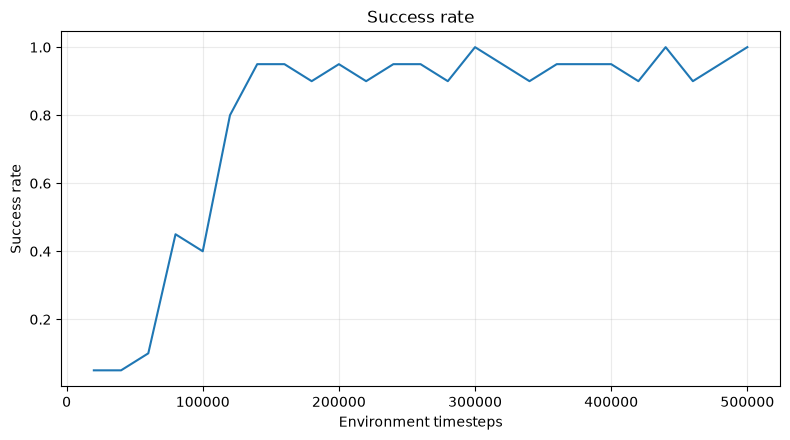

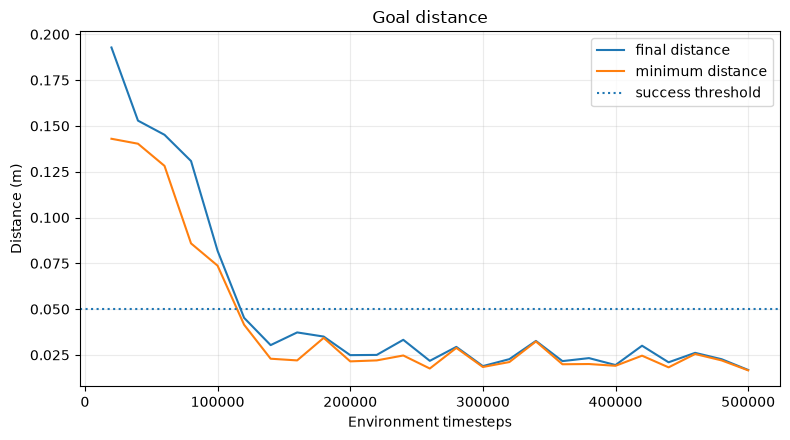

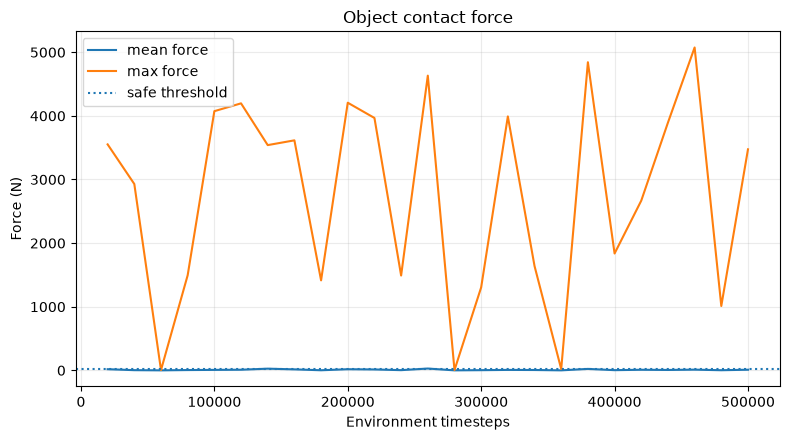

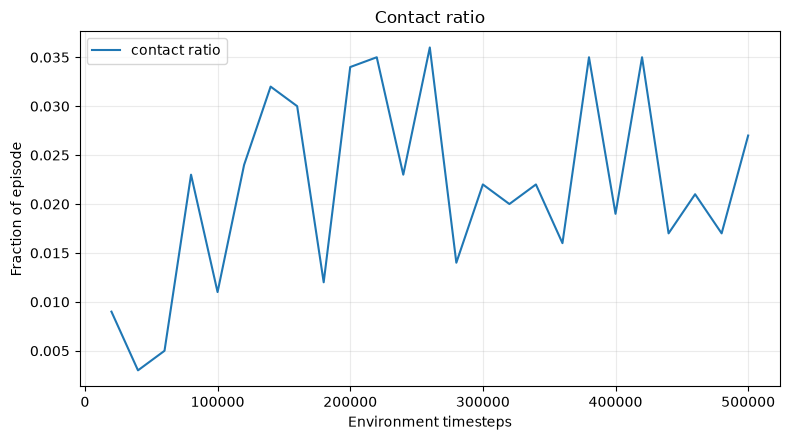

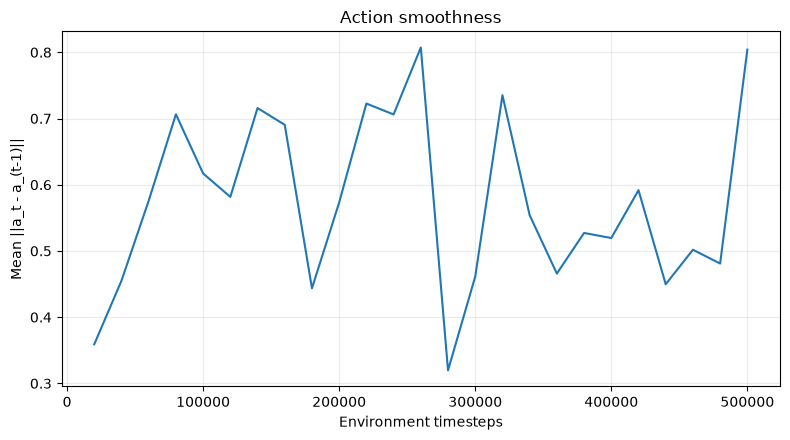

In [12]:
eval_csv = (
    EVAL_DIR
    / f"{RUN_NAME}_eval.csv"
)

df = pd.read_csv(eval_csv)
display(df.tail(20))


plt.figure(figsize=(8, 4.5))
plt.plot(
    df["timesteps"],
    df["success_rate"],
)

if REWARD_SCHEME == "dense2sparse":
    plt.axvline(
        SWITCH_STEP,
        linestyle="--",
        label="Dense -> Sparse",
    )

plt.xlabel("Environment timesteps")
plt.ylabel("Success rate")
plt.title("Success rate")
plt.grid(alpha=0.25)
plt.legend() if REWARD_SCHEME == "dense2sparse" else None
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 4.5))
plt.plot(
    df["timesteps"],
    df["mean_final_distance"],
    label="final distance",
)
plt.plot(
    df["timesteps"],
    df["mean_min_distance"],
    label="minimum distance",
)
plt.axhline(
    D_SUCCESS,
    linestyle=":",
    label="success threshold",
)

if REWARD_SCHEME == "dense2sparse":
    plt.axvline(
        SWITCH_STEP,
        linestyle="--",
        label="Dense -> Sparse",
    )

plt.xlabel("Environment timesteps")
plt.ylabel("Distance (m)")
plt.title("Goal distance")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 4.5))
plt.plot(
    df["timesteps"],
    df["mean_force"],
    label="mean force",
)
plt.plot(
    df["timesteps"],
    df["max_force"],
    label="max force",
)
plt.axhline(
    FORCE_SAFE,
    linestyle=":",
    label="safe threshold",
)

if REWARD_SCHEME == "dense2sparse":
    plt.axvline(
        SWITCH_STEP,
        linestyle="--",
        label="Dense -> Sparse",
    )

plt.xlabel("Environment timesteps")
plt.ylabel("Force (N)")
plt.title("Object contact force")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 4.5))
plt.plot(
    df["timesteps"],
    df["contact_ratio"],
    label="contact ratio",
)
plt.xlabel("Environment timesteps")
plt.ylabel("Fraction of episode")
plt.title("Contact ratio")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 4.5))
plt.plot(
    df["timesteps"],
    df["mean_action_delta"],
)
plt.xlabel("Environment timesteps")
plt.ylabel("Mean ||a_t - a_(t-1)||")
plt.title("Action smoothness")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 13. 最终 100 回合确定性评估

In [13]:
if REWARD_SCHEME == "dense2sparse":
    eval_env.set_reward_mode("sparse")

N_FINAL_EVAL = 100
rows = []

for ep in range(N_FINAL_EVAL):
    obs, info = eval_env.reset(
        seed=SEED + 20_000 + ep
    )

    success = False
    final_distance = np.nan
    min_distance = np.inf

    forces = []
    contacts = []
    deltas = []

    native_return = 0.0
    task_return = 0.0

    for t in range(
        MAX_EPISODE_STEPS
    ):
        action, _ = model.predict(
            obs,
            deterministic=True,
        )

        (
            obs,
            reward,
            terminated,
            truncated,
            info,
        ) = eval_env.step(action)

        native_return += float(reward)
        task_return += float(
            info["task_reward"]
        )

        d = float(
            info["distance_to_goal"]
        )

        final_distance = d
        min_distance = min(
            min_distance,
            d,
        )

        success |= bool(
            info["is_success"]
        )

        forces.append(
            float(info["force_norm"])
        )
        contacts.append(
            float(info["in_contact"])
        )
        deltas.append(
            float(
                info[
                    "action_delta_norm"
                ]
            )
        )

        if terminated or truncated:
            break

    rows.append(
        {
            "episode": ep,
            "success": float(success),
            "final_distance": final_distance,
            "min_distance": min_distance,
            "native_return": native_return,
            "task_return": task_return,
            "mean_force": float(
                np.mean(forces)
            ),
            "max_force": float(
                np.max(forces)
            ),
            "contact_ratio": float(
                np.mean(contacts)
            ),
            "mean_action_delta": float(
                np.mean(deltas)
            ),
        }
    )


final_df = pd.DataFrame(rows)

final_path = (
    EVAL_DIR
    / f"{RUN_NAME}_final_eval.csv"
)

final_df.to_csv(
    final_path,
    index=False,
)

print(
    "Success rate:",
    final_df["success"].mean(),
)

print(
    "Mean final distance:",
    final_df[
        "final_distance"
    ].mean(),
    "m",
)

print(
    "Mean min distance:",
    final_df[
        "min_distance"
    ].mean(),
    "m",
)

print(
    "Mean force:",
    final_df["mean_force"].mean(),
    "N",
)

print(
    "Worst max force:",
    final_df["max_force"].max(),
    "N",
)

print(
    "Mean contact ratio:",
    final_df[
        "contact_ratio"
    ].mean(),
)

print(
    "Mean action delta:",
    final_df[
        "mean_action_delta"
    ].mean(),
)

display(
    final_df.describe()
)

print("Saved:", final_path)

Success rate: 0.96
Mean final distance: 0.024332997929546588 m
Mean min distance: 0.021533696885039283 m
Mean force: 22.88401685109138 N
Worst max force: 5183.1689453125 N
Mean contact ratio: 0.0296
Mean action delta: 0.7709973549935184


,episode,success,final_distance,min_distance,native_return,task_return,mean_force,max_force,contact_ratio,mean_action_delta
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,49.500000,0.960000,0.024333,0.021534,-8.460650,-8.460650,22.884017,333.312086,0.029600,0.770997
std,29.011492,0.196946,0.026886,0.020702,11.739676,11.739676,113.977293,1096.578258,0.057312,0.495696
min,0.000000,0.000000,0.002460,0.002460,-58.876524,-58.876524,0.000000,0.000000,0.000000,0.086094
25%,24.750000,1.000000,0.012363,0.011581,-8.214797,-8.214797,0.000000,0.000000,0.000000,0.368806
50%,49.500000,1.000000,0.018976,0.018481,-5.000000,-5.000000,0.055313,2.524539,0.020000,0.682696
75%,74.250000,1.000000,0.025999,0.022988,-4.000000,-4.000000,0.141275,4.299579,0.040000,1.094057
max,99.000000,1.000000,0.195391,0.151809,0.000000,0.000000,790.361666,5183.168945,0.360000,2.448040


Saved: /root/autodl-tmp/franka_force_feedback/SAC_HER_Force_distance_layered_force_obs_only_seed42_20260901_144757/eval/SAC_HER_Force_distance_layered_force_obs_only_seed42_20260901_144757_final_eval.csv


## 14. 建议的进一步消融矩阵

在基础 A/B 奖励消融完成后，可以依次做：

| 实验 | Force obs | Smoothing | Force penalty | 目的 |
|---|---:|---:|---:|---|
| Baseline | × | × | × | 原始基线 |
| ForceObs | ✓ | × | × | 只验证力感知是否提升策略 |
| ForceObs+Smooth | ✓ | ✓ | × | 验证执行平滑性 |
| ForceSafe | ✓ | ✓ | ✓ | 验证安全接触/力限制 |

正式结果建议至少：

- seed = 42
- seed = 43
- seed = 44

统一比较：

- Success Rate
- Final / Minimum Distance
- Mean / Max Force
- Contact Ratio
- Action Delta
- 训练过程收敛曲线

这样项目可以从“奖励函数设计”进一步升级到：

> **接触感知 + 安全约束 + 强化学习机械臂控制**